In [311]:
import pandas as pd
import itertools

def generate_label_combinations(nodes_path, edges_path):
    # Load the graph data
    nodes = pd.read_csv(nodes_path)
    edges = pd.read_csv(edges_path)

    # Create a dictionary for quick ID -> Label lookup
    id_to_label = dict(zip(nodes['Id'], nodes['Label']))

    # 1. Identify Implementations (Layer 4)
    implementations = nodes[nodes['Layer'] == 'Layer 4']['Id'].tolist()
    
    simulation_results = []

    for impl in implementations:
        # Get labels instead of IDs for each category
        def get_labels(edge_type):
            targets = edges[(edges['Source'] == impl) & (edges['Type'] == edge_type)]['Target']
            return [id_to_label.get(t, t) for t in targets]

        suites = get_labels('offers_suite')
        groups = get_labels('offers_group')
        sigs   = get_labels('offers_sig_alg')

        # --- SIMULATION RULES ---
        impl_label = id_to_label.get(impl, impl)

        if "gmssl" in impl.lower():
            # TLCP: Use the human-readable Label for the hardcoded path
            # We know it's SM2 Key Exchange + SM4 Cipher + SM3 Hash
            simulation_results.append({
                "Implementation": impl_label,
                "Combination": "ECC-SM2 / ECC_SM4_CBC_SM3 / SM2-with-SM3 ",
                "Count": 1
            })
        
        else:
            # TLS 1.3: Generate Cartesian Product using Labels
            combinations = list(itertools.product(groups, suites, sigs))
            for combo in combinations:
                simulation_results.append({
                    "Implementation": impl_label,
                    "Combination": " / ".join(combo),
                    "Count": len(combinations)
                })

    return pd.DataFrame(simulation_results)

# Display results in the Notebook
df = generate_label_combinations('nodes.csv', 'edges.csv')
df.to_csv("combinations.csv")


In [312]:
import yaml
import os

# --- PREDEFINED PRIMITIVE PROFILES ---
# This dictionary complements your ClientHello data with hidden mathematical metadata
PRIMITIVE_PROFILES = {
    "ffdhe4096": {"role": "Key_Exchange", "math": "Finite Field DH", "bits": 4096, "qsi": 0.0},
    "SM2": {"role": "Key_Exchange", "math": "Elliptic Curve (SM2)", "curve": "sm2p256v1", "qsi": 0.0},
    "SM4": {"role": "Encryption", "math": "Symmetric Block Cipher", "bits": 128, "qsi": 0.5},
    "SM3": {"role": "Hash", "math": "Cryptographic Hash", "bits": 256, "qsi": 0.9},
    "TLS_AES_128_GCM_SHA256": {"role": "Encryption", "math": "AES-GCM", "bits": 128, "qsi": 0.5},
    "rsa_pss_rsae_sha384": {"role": "Authentication", "math": "RSA-PSS", "baseline": "RSA-2048", "qsi": 0.0}
}

def hydrate_combinations(combinations):
    hydrated_data = []

    for i, entry in enumerate(combinations):
        impl = entry["Implementation"]
        # Split combination string (e.g., "SM2 / SM4 / SM3")
        parts = [p.strip() for p in entry["Combination"].split('/')]
        
        # Create the Supernode (Composition)
        composition = {
            "composition_id": f"supernode_{i:03d}",
            "implementation": impl,
            "label": entry["Combination"],
            "primitives": []
        }

        # Hydrate each part into a full primitive profile
        for part in parts:
            profile = PRIMITIVE_PROFILES.get(part, {"id": part, "qsi": "unknown"})
            # Ensure the specific ID is included
            profile["id"] = part
            composition["primitives"].append(profile)

        hydrated_data.append(composition)
    
    return hydrated_data

# --- TEST DATA: YOUR FIRST THREE COMBINATIONS ---
raw_combinations = [
    {"Implementation": "GmSSL 3.1.2 Dev", "Combination": "SM2 / SM4 / SM3"},
    {"Implementation": "OpenSSL 3.0.17", "Combination": "ffdhe4096 / TLS_AES_128_GCM_SHA256 / rsa_pss_rsae_sha384"},
    {"Implementation": "OpenSSL 3.0.17", "Combination": "secp256r1 / TLS_AES_256_GCM_SHA384 / ecdsa_secp256r1_sha256"}
]

# Run the Hydration
cbom_output = hydrate_combinations(raw_combinations)

# Save to YAML
with open('cryptographic_inventory.yaml', 'w') as f:
    yaml.dump(cbom_output, f, sort_keys=False)

print(f"[*] Success: Hydrated {len(cbom_output)} combinations into 'cryptographic_inventory.yaml'")

[*] Success: Hydrated 3 combinations into 'cryptographic_inventory.yaml'


In [ ]:
import yaml
import os
import pandas as pd
from pathlib import Path

# --- DYNAMIC PATH CONFIGURATION ---
# Goes up 2 levels from your Notebook location to find the 'yaml' folder IANA MAPPER!!***
BASE_DIR = Path.cwd().parent.parent
YAML_ROOT = BASE_DIR / "yaml"
STANDARD_DIR = YAML_ROOT / "standard"
EXTENSIONS_DIR = YAML_ROOT / "extensions"

def build_primitive_registry():
    registry = {}
    print(f"[*] Scanning: {YAML_ROOT}")

    if not STANDARD_DIR.exists():
        print(f"[!] Error: Path not found: {STANDARD_DIR}")
        return registry

    # Iterate through 'standard' folder
    for std_file in STANDARD_DIR.glob("*.yaml"):
        try:
            with open(std_file, 'r') as f:
                base_data = yaml.safe_load(f)
                base_id = base_data.get('id')
                
                # Link base ID to metadata
                registry[base_id] = base_data
                
                # Search for matching extension file
                # Assuming: dhe.yaml -> dhe.extensions.yaml
                ext_name = std_file.name.replace(".yaml", ".extensions.yaml")
                ext_file = EXTENSIONS_DIR / ext_name
                
                if ext_file.exists():
                    with open(ext_file, 'r') as fe:
                        ext_data = yaml.safe_load(fe)
                        # Map all variants (like ffdhe4096) back to this base math
                        for var in ext_data.get('variants', []):
                            var_id = var.get('id')
                            # Merge: Standard Math + Variant Specifics
                            registry[var_id] = {**base_data, **var, "base_id": base_id}
        
        except yaml.YAMLError as exc:
            print(f"[!] YAML Error in file {std_file.name if 'std_file' in locals() else 'unknown'}:")
            if hasattr(exc, 'problem_mark'):
                mark = exc.problem_mark
                print(f"    Error on line {mark.line + 1}, column {mark.column + 1}")
            continue

    return registry

# Initialize the actual registry
primitive_lookup = build_primitive_registry()
print(primitive_lookup)
print(f"[*] Successfully loaded {len(primitive_lookup)} primitives/variants.")

[*] Scanning: c:\Users\ANDRES FELIPE\Documents\BIT\Master\Papers_Thesis\Paper_Elsevir\Quantum-Risk-Assessment-Framework\yaml
{'aes': {'id': 'aes', 'oid': '2.16.840.1.101.3.4.1', 'name': 'Advanced Encryption Standard', 'cryptoClass': 'Symmetric-Key-Algorithm/Block-Cipher', 'commonkeySize': '256', 'specifiedkeySize': '{min: 128, max: 256}'}, 'aes-128': {'id': 'aes-128', 'oid': '2.16.840.1.101.3.4.1.2', 'name': 'aes-128', 'cryptoClass': 'Symmetric-Key-Algorithm/Block-Cipher', 'commonkeySize': '256', 'specifiedkeySize': '{min: 128, max: 256}', 'securityLevel': 128, 'nistsecuritycategory': 1, 'q_p': 0.5, 'base_id': 'aes'}, 'aes-192': {'id': 'aes-192', 'oid': '2.16.840.1.101.3.4.1.22', 'name': 'aes-192', 'cryptoClass': 'Symmetric-Key-Algorithm/Block-Cipher', 'commonkeySize': '256', 'specifiedkeySize': '{min: 128, max: 256}', 'securityLevel': 192, 'nistsecuritycategory': 3, 'q_p': 0.25, 'base_id': 'aes'}, 'aes-256': {'id': 'aes-256', 'oid': '2.16.840.1.101.3.4.1.42', 'name': 'aes-256', 'crypt

In [314]:
import yaml
import os
from pathlib import Path
import json

# --- PATH CONFIGURATION ---
BASE_DIR = Path.cwd().parent.parent
YAML_ROOT = BASE_DIR / "yaml"
STANDARD_DIR = YAML_ROOT / "standard"
EXTENSIONS_DIR = YAML_ROOT / "extensions"

def build_primitive_registry():
    registry = {}
    
    for std_file in STANDARD_DIR.glob("*.yaml"):
        with open(std_file, 'r') as f:
            base_data = yaml.safe_load(f)
            base_id = base_data.get('id') # e.g., 'ecdh' or 'ecdsa'
            
            registry[base_id] = base_data
            
            ext_file = EXTENSIONS_DIR / std_file.name.replace(".yaml", ".extensions.yaml")
            if ext_file.exists():
                with open(ext_file, 'r') as fe:
                    ext_data = yaml.safe_load(fe)
                    for var in ext_data.get('variants', []):
                        var_id = var.get('id')
                        if not var_id: continue

                        # Create the specific Namespace Key (e.g., 'ecdh:secp521r1')
                        namespace_key = f"{base_id}:{var_id}"
                        full_meta = {**base_data, **var, "parent_id": base_id}
                        
                        # Store both! 
                        # 1. Namespace key for components (specific)
                        registry[namespace_key] = full_meta
                        
                        # 2. Short key for discovery (merged/general)
                        if var_id in registry:
                            registry[var_id].update(full_meta)
                        else:
                            registry[var_id] = full_meta
                
    return registry

def hydrate_supernode(combination_str, registry):
    parts = [p.strip() for p in combination_str.split('/')]
    hydrated_primitives = []
    
    for part in parts:
        # 1. Primary Lookup (The Variant/Suite)
        metadata = registry.get(part, {"id": part}).copy()
        
        # 2. Resolve Components
        if "components" in metadata:
            resolved_components = {}
            for key, component_id in metadata["components"].items():
                
                # Fetch the sub-primitive
                sub_meta = registry.get(component_id)
                
                if not sub_meta:
                    search_id = component_id.split(':')[-1]
                    sub_meta = registry.get(search_id, {"id": search_id, "status": "MISSING"}).copy()
                else:
                    sub_meta = sub_meta.copy()

                # --- THE ATOMIC STRIPPER ---
                # If we are resolving a component, we don't want it to 
                # carry its own 'components' or 'resolved_components' list.
                # This makes it a clean "Leaf Node".
                sub_meta.pop("components", None)
                sub_meta.pop("resolved_components", None)
                
                resolved_components[key] = sub_meta
            
            metadata["resolved_components"] = resolved_components
            
        hydrated_primitives.append(metadata)
        
    return hydrated_primitives

# --- EXECUTION ---
primitive_registry = build_primitive_registry()

supernode_str = "ECC-SM2 / ECC_SM4_CBC_SM3 / SM2-with-SM3"
full_inventory = hydrate_supernode(supernode_str, primitive_registry)

print(f"--- FULL HYDRATION REPORT FOR SUPERNODE ---")
for i, primitive in enumerate(full_inventory):
    role = ["KEY EXCHANGE", "CIPHER SUITE", "SIGNATURE"][i]
    print(f"=== Component {i+1}: {role} ===")
    print(yaml.dump(primitive, sort_keys=False, default_flow_style=False))
    print("-" * 40)

with open('supernode_hydration_debug.yaml', 'w') as f:
    yaml.dump(full_inventory, f, sort_keys=False, default_flow_style=False)

# Save as JSON (Standard for discovery tools)
with open('supernode_hydration_debug.json', 'w') as f:
    json.dump(full_inventory, f, indent=4)

print("[*] Full hydration saved to 'supernode_hydration_debug.yaml'. Open it to see every component!")

--- FULL HYDRATION REPORT FOR SUPERNODE ---
=== Component 1: KEY EXCHANGE ===
id: ECC-SM2
name: sm2p256v1
cryptoClass: Symmetric-Key-Algorithm/Block-Cipher
standard: null
gmssl_oid: 1.2.156.10197.1.301
components:
  primitive: sm2:SM2
parent_id: tlcp-groups
resolved_components:
  primitive:
    id: SM2
    name: sm2p256v1
    cryptoClass: Asymmetric-Key-Algorithm/Public-Key-Cipher
    oid: null
    commonkeySize: '256'
    securityLevel: 128
    q_p: 0.75
    parent_id: SM2

----------------------------------------
=== Component 2: CIPHER SUITE ===
id: ECC_SM4_CBC_SM3
name: TLCP Cipher Suite
cryptoClass: Protocol/Cipher-Suite
standard: null
gmssl_oid: null
components:
  primitive: sms4:SMS4
  mode: mode:cbc
  hash: sm3:SM3
parent_id: tlcp-suites
resolved_components:
  primitive:
    id: SMS4
    name: sm4
    cryptoClass: Symmetric-Key-Algorithm/Block-Cipher
    oid: null
    commonkeySize: '128'
    securityLevel: 128
    q_p: 0.5
    parent_id: SMS4
  mode:
    id: cbc
    status: MI

In [341]:
import csv
import json
import yaml

# --- EXECUTION: MASS HYDRATION ---
primitive_registry = build_primitive_registry()
master_hydrated_inventory = []

# Assuming your CSV from the discovery phase is named 'combinations.csv'
combinations_file = 'combinations.csv' 

print(f"[*] Starting Mass Hydration of {combinations_file}...")

try:
    with open(combinations_file, mode='r', encoding='utf-8') as f:
        # We use DictReader to handle CSV columns automatically
        reader = csv.DictReader(f) 
        
        for row in reader:
            # We look for the 'combination' column (e.g., "ffdhe4096 / TLS_AES... / rsa_...")
            combo_str = row.get('Combination')
            implementation = row.get('Implementation', '')
            
            if combo_str:
                # 1. Perform the 3-layer recursive hydration
                implementation = implementation.replace("Implementation:", "").strip()
                hydrated_data = hydrate_supernode(combo_str, primitive_registry)
                
                # 2. Bundle everything together
                # We include the original CSV row data (like 'count' or 'occurrence')
                protocol_label = "TLCP" if "GmSSL" in implementation else "TLS 1.3"
                entry = {
                    "Origin": "Local_Research_Node", 
                    "Domain": "Data In Transit",
                    "Protocol": protocol_label,
                    "Implementation": implementation,
                    "supernode_id": combo_str,
                    "discovery_metadata": dict(row),
                    "composition": hydrated_data
                }
                master_hydrated_inventory.append(entry)

    print(f"[*] Successfully processed {len(master_hydrated_inventory)} supernodes.")

    # --- 2. EXPORT TO JSON (Programmatic Standard) ---
    json_output = 'master_hydrated_inventory.json'
    with open(json_output, 'w', encoding='utf-8') as jf:
        json.dump(master_hydrated_inventory, jf, indent=4)
    print(f"[*] JSON Inventory saved to {json_output}")

    # --- 3. EXPORT TO YAML (Human Readable Standard) ---
    yaml_output = 'master_hydrated_inventory.yaml'
    with open(yaml_output, 'w', encoding='utf-8') as yf:
        yaml.dump(master_hydrated_inventory, yf, sort_keys=False, default_flow_style=False)
    print(f"[*] YAML Inventory saved to {yaml_output}")

except FileNotFoundError:
    print(f"[!] Error: {combinations_file} not found. Ensure the file is in the same directory.")

[*] Starting Mass Hydration of combinations.csv...
[*] Successfully processed 241 supernodes.
[*] JSON Inventory saved to master_hydrated_inventory.json
[*] YAML Inventory saved to master_hydrated_inventory.yaml


In [342]:
import json
import pandas as pd
from collections import Counter

def export_gephi_with_centrality(json_file):
    with open(json_file, 'r') as f:
        inventory = json.load(f)

    nodes_metadata = {}
    edges = []
    centrality_counter = Counter()

    def add_node_data(node_id, label, node_type, **kwargs):
        if node_id not in nodes_metadata:
            nodes_metadata[node_id] = {
                "Id": node_id, 
                "Label": label, 
                "Type": node_type
            }
        for key, value in kwargs.items():
            if value is not None:
                nodes_metadata[node_id][key] = value

    def add_edge(source, target, label):
        edges.append({
            "Source": source, 
            "Target": target, 
            "Type": "Directed", 
            "Label": label
        })
        centrality_counter[target] += 1

    for entry in inventory:
        origin = entry.get("Origin")
        domain = entry.get("Domain")
        protocol = entry.get("Protocol")
        impl = entry.get("Implementation")
        sn_id = entry.get("supernode_id", "").strip()

        add_node_data(origin, origin, "Origin")
        add_node_data(domain, domain, "Domain")
        add_node_data(protocol, protocol, "Protocol")
        add_node_data(impl, impl, "Implementation")
        add_node_data(sn_id, sn_id, "Supernode")

        add_edge(origin, domain, "contains")
        add_edge(domain, protocol, "carries")
        add_edge(protocol, impl, "implemented_by")
        add_edge(impl, sn_id, "negotiates")

        for variant in entry.get("composition", []):
            resolved = variant.get("resolved_components", {})
            for comp_key, comp_val in resolved.items():
                if comp_key == "mode": continue 
                
                atom_id = comp_val.get("id")
                if atom_id:
                    add_node_data(
                        atom_id, 
                        comp_val.get("name", atom_id), 
                        "Primitive",
                        section=comp_key.upper(), # Adds KEX, SIG, or CIPHER
                        q_p=comp_val.get("q_p"),
                        css_qp=comp_val.get("css_q_p"),
                        pims_qp=comp_val.get("pims_q_p"),
                        sec_level=comp_val.get("securityLevel")
                    )
                    add_edge(sn_id, atom_id, "uses")

    # Final logic for clean labels and centrality
    final_nodes_list = []
    for node_id, data in nodes_metadata.items():
        data["Centrality_Score"] = centrality_counter[node_id]
        
        # NEW LOGIC: Create a label column that ignores Supernodes
        if data["Type"] == "Supernode":
            data["label_primitives"] = "" # Empty string for Gephi
        else:
            data["label_primitives"] = data["Label"]
            
        final_nodes_list.append(data)

    pd.DataFrame(final_nodes_list).to_csv("nodes_combinations.csv", index=False)
    pd.DataFrame(edges).to_csv("edges_combinations.csv", index=False)
    
    print(f"Success: {len(final_nodes_list)} nodes exported.")
    print("Column 'label_primitives' added for clean visualization.")

if __name__ == "__main__":
    export_gephi_with_centrality('master_hydrated_inventory.json')

Success: 273 nodes exported.
Column 'label_primitives' added for clean visualization.


Optimizing label placement...
Final visualization saved as 'PrimitiveQuantumRiskQuadrant.png'


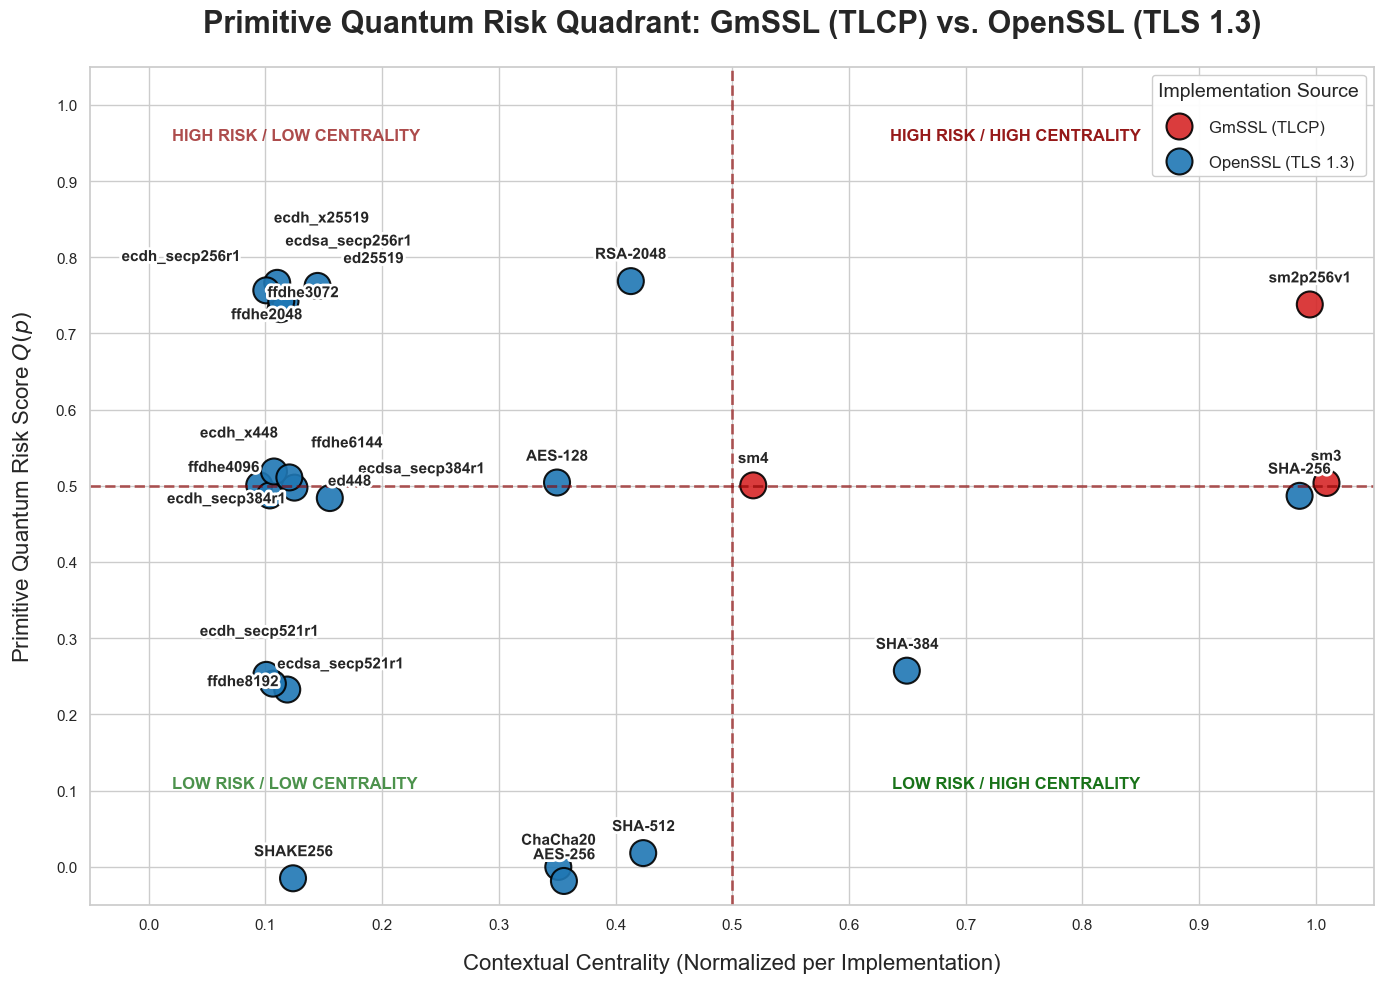

In [343]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import defaultdict
from matplotlib.patheffects import withStroke

# --- Custom Function to Adjust Label Positions Iteratively (No Overlap) ---
def adjust_labels_iteratively(texts, ax, max_iterations=150, repulsion=0.02):
    fig = ax.get_figure()
    try: fig.canvas.draw()
    except: pass 
    
    renderer = fig.canvas.get_renderer()
    transDataInv = ax.transData.inverted()

    for i in range(max_iterations):
        moved_any = False
        extents = [t.get_window_extent(renderer).transformed(transDataInv) for t in texts]
        positions = [t.get_position() for t in texts]

        for j in range(len(texts)):
            for k in range(j + 1, len(texts)):
                if extents[j].overlaps(extents[k]):
                    x1, y1 = positions[j]
                    x2, y2 = positions[k]
                    dx, dy = x1 - x2, y1 - y2
                    
                    if abs(dx) < 0.0001: dx = np.random.uniform(-0.001, 0.001)
                    if abs(dy) < 0.0001: dy = np.random.uniform(0.001, 0.01)

                    length = np.sqrt(dx*dx + dy*dy)
                    if length == 0: length = 0.01
                    dx /= length
                    dy /= length

                    move_x = dx * repulsion * 0.8
                    move_y = dy * repulsion * 1.2
                    
                    texts[j].set_position((x1 + move_x, y1 + move_y))
                    texts[k].set_position((x2 - move_x, y2 - move_y))
                    moved_any = True
        if not moved_any: break

def generate_final_implementation_quadrant(input_file="nodes_combinations.csv"):
    try:
        df_raw = pd.read_csv(input_file)
        df_raw["Label"] = df_raw["Label"].str.replace(r'aes-128', 'AES-128', case=False, regex=True)
        df_raw["Label"] = df_raw["Label"].str.replace(r'aes-256', 'AES-256', case=False, regex=True)
    except Exception as e:
        print(f"Error loading data: {e}")
        return

    df = df_raw[df_raw["Type"] == "Primitive"].copy()
    if df.empty:
        print("No primitives found.")
        return

    def categorize_impl(label):
        label_up = str(label).upper()
        if any(sm in label_up for sm in ["SM2", "SM3", "SM4", "SMS4"]):
            return "GmSSL (TLCP)"
        return "OpenSSL (TLS 1.3)"

    df["Implementation_Source"] = df["Label"].apply(categorize_impl)
    df["q_p_effective"] = df["q_p"].fillna(df["css_qp"])

    # === NEW: Grouped Centrality Normalization ===
    # This ensures relative importance is shown per implementation
    df["centrality_weight"] = df.groupby("Implementation_Source")["Centrality_Score"].transform(
        lambda x: x / x.max() if x.max() > 0 else 0
    )

    jitter = 0.02
    np.random.seed(42) 
    df["x_plot"] = df["centrality_weight"] + np.random.uniform(-jitter, jitter, len(df))
    df["y_plot"] = df["q_p_effective"] + np.random.uniform(-jitter, jitter, len(df))

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(14, 10))

    palette = {"GmSSL (TLCP)": "#D62728", "OpenSSL (TLS 1.3)": "#1F77B4"}

    ax.axhline(0.5, color='darkred', linestyle='--', linewidth=2, alpha=0.6)
    ax.axvline(0.5, color='darkred', linestyle='--', linewidth=2, alpha=0.6)

    ax.text(0.02, 0.97, "HIGH RISK / LOW CENTRALITY", 
            fontsize=12, color='darkred', alpha=0.7, fontweight='bold', ha='left', va='top')
    ax.text(0.85, 0.97, "HIGH RISK / HIGH CENTRALITY", 
            fontsize=12, color='darkred', alpha=0.9, fontweight='bold', ha='right', va='top')
    ax.text(0.02, 0.10, "LOW RISK / LOW CENTRALITY", 
            fontsize=12, color='darkgreen', alpha=0.7, fontweight='bold', ha='left', va='bottom')
    ax.text(0.85, 0.10, "LOW RISK / HIGH CENTRALITY", 
            fontsize=12, color='darkgreen', alpha=0.9, fontweight='bold', ha='right', va='bottom')

    sns.scatterplot(
        data=df, x="x_plot", y="y_plot", 
        hue="Implementation_Source", palette=palette,
        s=350, edgecolor="black", linewidth=1.5, alpha=0.9, ax=ax
    )

    texts = []
    label_coords = defaultdict(list)
    for _, row in df.iterrows():
        key = (round(row["x_plot"], 3), round(row["y_plot"], 3))
        label_coords[key].append(row["Label"])

    for (x, y), names in label_coords.items():
        label_text = "\n".join(sorted(set(names)))
        txt = ax.text(
            x, y + 0.025, label_text,
            fontsize=11, fontweight="bold", ha="center", va="bottom",
            path_effects=[withStroke(linewidth=4, foreground='white')]
        )
        texts.append(txt)

    print("Optimizing label placement...")
    adjust_labels_iteratively(texts, ax, max_iterations=200, repulsion=0.02)

    ax.set_title("Primitive Quantum Risk Quadrant: GmSSL (TLCP) vs. OpenSSL (TLS 1.3)", fontsize=22, pad=25, fontweight='bold')
    ax.set_xlabel("Contextual Centrality (Normalized per Implementation)", fontsize=16, labelpad=15)
    ax.set_ylabel("Primitive Quantum Risk Score $Q(p)$", fontsize=16, labelpad=15)
    
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_yticks(np.arange(0, 1.1, 0.1))

    plt.legend(title="Implementation Source", fontsize=12, title_fontsize=14, loc="upper right", framealpha=0.95,labelspacing=1.2)
    
    plt.tight_layout()
    output_filename = "PrimitiveQuantumRiskQuadrant.png"
    plt.savefig(output_filename, dpi=300)
    print(f"Final visualization saved as '{output_filename}'")

generate_final_implementation_quadrant()

Professional heatmap saved as 'Centrality_Heatmap.png'


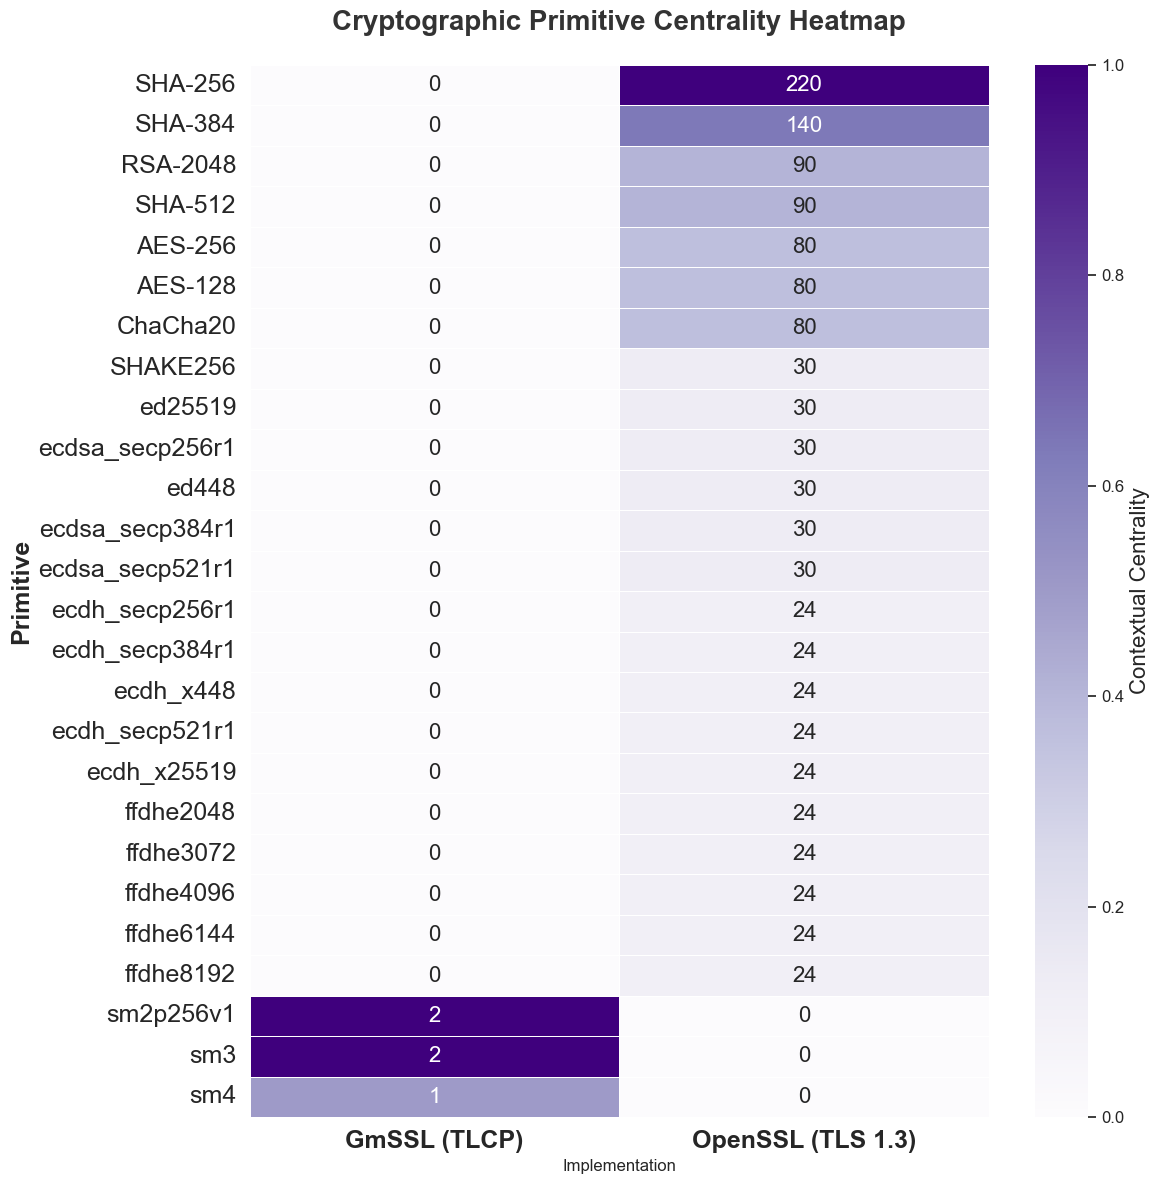

In [344]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def generate_professional_heatmap(input_file="nodes_combinations.csv"):
    # 1. Load Data
    try:
        df_raw = pd.read_csv(input_file)
        df_raw["Label"] = df_raw["Label"].str.replace(r'aes-128', 'AES-128', case=False, regex=True)
        df_raw["Label"] = df_raw["Label"].str.replace(r'aes-256', 'AES-256', case=False, regex=True)
    except Exception as e:
        print(f"Error loading data: {e}")
        return

    # Filter for Primitives
    df = df_raw[df_raw["Type"] == "Primitive"].copy()
    
    # 2. Categorize Implementation Stack
    def categorize_impl(label):
        label_up = str(label).upper()
        if any(sm in label_up for sm in ["SM2", "SM3", "SM4", "SMS4"]):
            return "GmSSL (TLCP)"
        return "OpenSSL (TLS 1.3)"
    
    df["Implementation"] = df["Label"].apply(categorize_impl)

    # 3. Calculate Saturation for Color Logic
    df["Saturation"] = df.groupby("Implementation")["Centrality_Score"].transform(
        lambda x: x / x.max() if x.max() > 0 else 0
    )
    
    # 4. Create Pivot Tables
    # color_df controls the depth of the purple
    color_df = df.pivot_table(index="Label", columns="Implementation", 
                             values="Saturation", fill_value=0)
    
    # count_df controls the numbers shown in the cells
    count_df = df.pivot_table(index="Label", columns="Implementation", 
                             values="Centrality_Score", fill_value=0)

    # Sort rows by total discovery count so the "heavy hitters" are at the top
    color_df["total"] = count_df.sum(axis=1)
    color_df = color_df.sort_values(by="total", ascending=False).drop(columns="total")
    count_df = count_df.reindex(color_df.index)

    # 5. Plotting
    plt.figure(figsize=(12, 12))
    sns.set_theme(style="whitegrid")

    # Using 'BuPu' (Blue-Purple) or 'Purples' for that professional research look
    ax = sns.heatmap(
        color_df, 
        annot=count_df.astype(int), 
        fmt="d", 
        cmap="Purples", 
        linewidths=0.7, 
        linecolor='white', # White lines look cleaner with dark colors
        annot_kws={"size": 16},
        cbar_kws={'label': 'Contextual Centrality'}
    )

    cbar = ax.collections[0].colorbar
    cbar.set_label('Contextual Centrality', size=16) # Size of the main title
    cbar.ax.tick_params(labelsize=12) # Size of the numbers (0.0, 0.2, etc.)

    # Formatting
    plt.title("Cryptographic Primitive Centrality Heatmap", 
              fontsize=20, pad=25, fontweight='bold', color='#333333')
    plt.ylabel("Primitive", fontsize=18, fontweight='bold')
    
    plt.xticks(rotation=0, fontsize=18, fontweight='bold')
    plt.yticks(fontsize=18)

    # Add the explanatory note at the bottom
    #plt.figtext(0.5, 0.01, 
     #           "Note: Cell numbers represent Raw In-Degree Centrality. Color intensity represents Contextual Saturation (0.0 to 1.0).", 
      #          wrap=True, horizontalalignment='center', fontsize=10, style='italic')

    plt.tight_layout()
    output_name = "Centrality_Heatmap.png"
    plt.savefig(output_name, dpi=300)
    print(f"Professional heatmap saved as '{output_name}'")
    plt.show()

# Run
generate_professional_heatmap()

In [345]:
import json
import pandas as pd

def calculate_handshake_risk(json_file):
    with open(json_file, 'r') as f:
        inventory = json.load(f)

    results = []

    for entry in inventory:
        total_q_risk = 0
        primitive_count = 0
        
        # We look into the composition which contains the 3 functional sections:
        # 0: Supported Groups (Key Exchange)
        # 1: Cipher Suites
        # 2: Signature Algorithms
        for section in entry.get("composition", []):
            resolved = section.get("resolved_components", {})
            
            for key, comp in resolved.items():
                if key == "mode": continue # Skip non-mathematical components
                
                # Get the effective quantum risk (q_p or css_qp)
                q_p = comp.get("q_p")
                if q_p is None:
                    q_p = comp.get("css_q_p", 0) # Fallback to collision risk or 0
                
                total_q_risk += q_p
                primitive_count += 1

        # Calculate the Average Handshake Risk
        handshake_risk_score = total_q_risk / primitive_count if primitive_count > 0 else 0

        results.append({
            "Supernode": entry.get("supernode_id"),
            "Implementation": entry.get("Implementation"),
            "Protocol": entry.get("Protocol"),
            "Total_Primitives": primitive_count,
            "Handshake_Risk_Score": round(handshake_risk_score, 4)
        })

    # Export to CSV for your final analysis
    df = pd.DataFrame(results)
    df.to_csv("handshake_risk_analysis.csv", index=False)
    
    # Summary for your thesis notes
    print("--- Risk Analysis Summary ---")
    print(df.groupby("Protocol")["Handshake_Risk_Score"].mean())
    return df

# Run the calculation
calculate_handshake_risk('master_hydrated_inventory.json')

--- Risk Analysis Summary ---
Protocol
TLCP       0.600000
TLS 1.3    0.389167
Name: Handshake_Risk_Score, dtype: float64


,Supernode,Implementation,Protocol,Total_Primitives,Handshake_Risk_Score
0,ECC-SM2 / ECC_SM4_CBC_SM3 / SM2-with-SM3,GmSSL 3.1.2 Dev,TLCP,5,0.60
1,ffdhe2048 / TLS_AES_128_GCM_SHA256 / ecdsa_sec...,OpenSSL 3.0.17,TLS 1.3,5,0.40
2,ffdhe2048 / TLS_AES_128_GCM_SHA256 / rsa_pss_r...,OpenSSL 3.0.17,TLS 1.3,5,0.60
3,ffdhe2048 / TLS_AES_128_GCM_SHA256 / ed25519,OpenSSL 3.0.17,TLS 1.3,5,0.50
4,ffdhe2048 / TLS_AES_128_GCM_SHA256 / ecdsa_sec...,OpenSSL 3.0.17,TLS 1.3,5,0.60
...,...,...,...,...,...
236,ffdhe6144 / TLS_AES_256_GCM_SHA384 / ecdsa_sec...,OpenSSL 3.0.17,TLS 1.3,5,0.40
237,ffdhe6144 / TLS_AES_256_GCM_SHA384 / ecdsa_sec...,OpenSSL 3.0.17,TLS 1.3,5,0.30
238,ffdhe6144 / TLS_AES_256_GCM_SHA384 / rsa_pss_r...,OpenSSL 3.0.17,TLS 1.3,5,0.35
239,ffdhe6144 / TLS_AES_256_GCM_SHA384 / ed448,OpenSSL 3.0.17,TLS 1.3,5,0.25


In [346]:
import json
import pandas as pd
import numpy as np

def calculate_detailed_handshake_risk(json_file):
    with open(json_file, 'r') as f:
        inventory = json.load(f)

    results = []

    for entry in inventory:
        # Initialize risk sums for the three pillars
        sums = {"KEX": 0, "SIG": 0, "CIPHER": 0}
        total_count = 0
        
        # We iterate through the composition
        # We'll use both the section index and cryptoclass for robust mapping
        for i, section in enumerate(entry.get("composition", [])):
            resolved = section.get("resolved_components", {})
            
            for key, comp in resolved.items():
                if key == "mode": continue
                
                # 1. Get the risk value
                q_p = comp.get("q_p")
                if q_p is None:
                    q_p = comp.get("css_q_p", 0)
                
                # 2. Categorize using cryptoclass
                c_class = str(comp.get("cryptoclass", "")).lower()
                
                # Logic: KEX (Groups), SIG (Signatures/Hash), CIPHER (Symmetric)
                if "public-key-cipher" in c_class or i == 0:
                    sums["KEX"] += q_p
                elif "digital-signature" in c_class or "hash-function" in c_class or i == 2:
                    sums["SIG"] += q_p
                elif "block-cipher" in c_class or i == 1:
                    sums["CIPHER"] += q_p
                
                total_count += 1

        # Calculate contributions to the total score
        # Segment_Contribution = Sum(Segment_Risks) / Total_Primitives
        if total_count > 0:
            kex_contrib = sums["KEX"] / total_count
            sig_contrib = sums["SIG"] / total_count
            cip_contrib = sums["CIPHER"] / total_count
            total_risk = kex_contrib + sig_contrib + cip_contrib
        else:
            kex_contrib = sig_contrib = cip_contrib = total_risk = 0

        results.append({
            "Supernode": entry.get("supernode_id"),
            "Implementation": entry.get("Implementation"),
            "Protocol": entry.get("Protocol"),
            "KEX_Contribution": round(kex_contrib, 4),
            "SIG_Contribution": round(sig_contrib, 4),
            "CIPHER_Contribution": round(cip_contrib, 4),
            "Handshake_Risk_Score": round(total_risk, 4)
        })

    df = pd.DataFrame(results)
    df.to_csv("handshake_detailed_risk.csv", index=False)
    print(f"Detailed analysis saved to 'handshake_detailed_risk.csv'")
    return df

# Run the extraction
df = calculate_detailed_handshake_risk('master_hydrated_inventory.json')
df

Detailed analysis saved to 'handshake_detailed_risk.csv'


,Supernode,Implementation,Protocol,KEX_Contribution,SIG_Contribution,CIPHER_Contribution,Handshake_Risk_Score
0,ECC-SM2 / ECC_SM4_CBC_SM3 / SM2-with-SM3,GmSSL 3.1.2 Dev,TLCP,0.15,0.25,0.20,0.60
1,ffdhe2048 / TLS_AES_128_GCM_SHA256 / ecdsa_sec...,OpenSSL 3.0.17,TLS 1.3,0.15,0.05,0.20,0.40
2,ffdhe2048 / TLS_AES_128_GCM_SHA256 / rsa_pss_r...,OpenSSL 3.0.17,TLS 1.3,0.15,0.25,0.20,0.60
3,ffdhe2048 / TLS_AES_128_GCM_SHA256 / ed25519,OpenSSL 3.0.17,TLS 1.3,0.15,0.15,0.20,0.50
4,ffdhe2048 / TLS_AES_128_GCM_SHA256 / ecdsa_sec...,OpenSSL 3.0.17,TLS 1.3,0.15,0.25,0.20,0.60
...,...,...,...,...,...,...,...
236,ffdhe6144 / TLS_AES_256_GCM_SHA384 / ecdsa_sec...,OpenSSL 3.0.17,TLS 1.3,0.10,0.25,0.05,0.40
237,ffdhe6144 / TLS_AES_256_GCM_SHA384 / ecdsa_sec...,OpenSSL 3.0.17,TLS 1.3,0.10,0.15,0.05,0.30
238,ffdhe6144 / TLS_AES_256_GCM_SHA384 / rsa_pss_r...,OpenSSL 3.0.17,TLS 1.3,0.10,0.20,0.05,0.35
239,ffdhe6144 / TLS_AES_256_GCM_SHA384 / ed448,OpenSSL 3.0.17,TLS 1.3,0.10,0.10,0.05,0.25


In [347]:
import json
import pandas as pd
import numpy as np

def calculate_detailed_handshake_risk(json_file):
    with open(json_file, 'r') as f:
        inventory = json.load(f)

    results = []

    for entry in inventory:
        # Initialize sums for the three segments
        sums = {"KEX": 0, "SIG": 0, "CIPHER": 0}
        total_count = 0
        
        composition = entry.get("composition", [])
        
        for i, section in enumerate(composition):
            resolved = section.get("resolved_components", {})
            
            for key, comp in resolved.items():
                if key == "mode": continue
                
                # Get the risk value
                q_p = comp.get("q_p")
                if q_p is None:
                    q_p = comp.get("css_q_p", 0)
                
                c_class = str(comp.get("cryptoclass", "")).lower()
                
                # Robust Categorization Logic:
                # 1. Check cryptoclass first
                # 2. Use index (i) as fallback
                if "public-key-cipher" in c_class or i == 0:
                    sums["KEX"] += q_p
                elif "block-cipher" in c_class or "symmetric" in c_class or i == 1:
                    sums["CIPHER"] += q_p
                elif "digital-signature" in c_class or "hash-function" in c_class or i == 2:
                    sums["SIG"] += q_p
                
                total_count += 1

        # Calculate contributions
        if total_count > 0:
            kex_c = sums["KEX"] / total_count
            sig_c = sums["SIG"] / total_count
            cip_c = sums["CIPHER"] / total_count
            total_r = kex_c + sig_c + cip_c
        else:
            kex_c = sig_c = cip_c = total_r = 0

        results.append({
            "Supernode": entry.get("supernode_id", "Unknown"),
            "Implementation": entry.get("Implementation", "Unknown"),
            "Protocol": entry.get("Protocol", "Unknown"),
            "KEX_Contribution": round(kex_c, 4),
            "SIG_Contribution": round(sig_c, 4),
            "CIPHER_Contribution": round(cip_c, 4),
            "Handshake_Risk_Score": round(total_r, 4)
        })

    df = pd.DataFrame(results)
    df.to_csv("handshake_detailed_risk.csv", index=False)
    return df

# Run this first
df_results = calculate_detailed_handshake_risk('master_hydrated_inventory.json')
df_results

,Supernode,Implementation,Protocol,KEX_Contribution,SIG_Contribution,CIPHER_Contribution,Handshake_Risk_Score
0,ECC-SM2 / ECC_SM4_CBC_SM3 / SM2-with-SM3,GmSSL 3.1.2 Dev,TLCP,0.15,0.25,0.20,0.60
1,ffdhe2048 / TLS_AES_128_GCM_SHA256 / ecdsa_sec...,OpenSSL 3.0.17,TLS 1.3,0.15,0.05,0.20,0.40
2,ffdhe2048 / TLS_AES_128_GCM_SHA256 / rsa_pss_r...,OpenSSL 3.0.17,TLS 1.3,0.15,0.25,0.20,0.60
3,ffdhe2048 / TLS_AES_128_GCM_SHA256 / ed25519,OpenSSL 3.0.17,TLS 1.3,0.15,0.15,0.20,0.50
4,ffdhe2048 / TLS_AES_128_GCM_SHA256 / ecdsa_sec...,OpenSSL 3.0.17,TLS 1.3,0.15,0.25,0.20,0.60
...,...,...,...,...,...,...,...
236,ffdhe6144 / TLS_AES_256_GCM_SHA384 / ecdsa_sec...,OpenSSL 3.0.17,TLS 1.3,0.10,0.25,0.05,0.40
237,ffdhe6144 / TLS_AES_256_GCM_SHA384 / ecdsa_sec...,OpenSSL 3.0.17,TLS 1.3,0.10,0.15,0.05,0.30
238,ffdhe6144 / TLS_AES_256_GCM_SHA384 / rsa_pss_r...,OpenSSL 3.0.17,TLS 1.3,0.10,0.20,0.05,0.35
239,ffdhe6144 / TLS_AES_256_GCM_SHA384 / ed448,OpenSSL 3.0.17,TLS 1.3,0.10,0.10,0.05,0.25


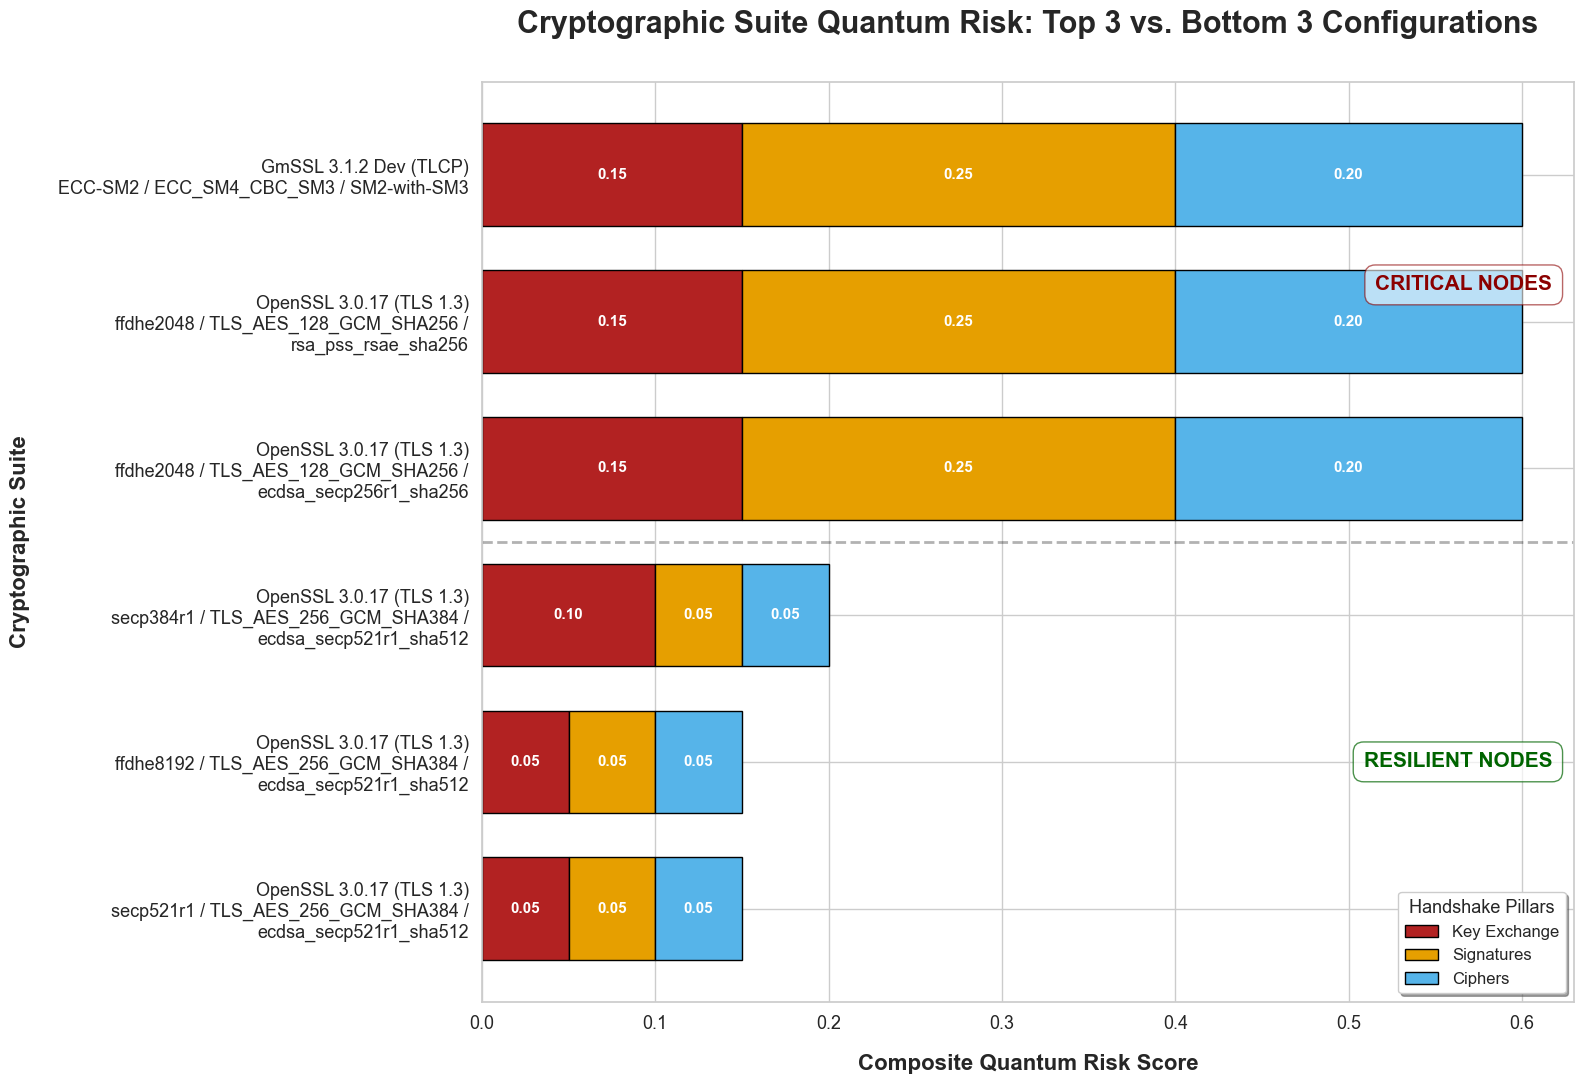

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import textwrap

def plot_wrapped_horizontal_with_internal_labels(csv_file="handshake_detailed_risk.csv"):
    # 1. Load Data
    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f"Error reading CSV: {e}")
        return

    # 2. Select Extremes (Top 3 and Bottom 3)
    df_sorted = df.sort_values(by="Handshake_Risk_Score", ascending=False)
    plot_df = pd.concat([df_sorted.head(3), df_sorted.tail(3)]).drop_duplicates().reset_index(drop=True)

    # 3. Label Logic: Wrap long Configs
    def clean_label(row):
        impl = str(row['Implementation'])
        proto = str(row['Protocol'])
        sn = str(row['Supernode'])
        # Wrap at 45 chars for horizontal clarity
        wrapped_sn = "\n".join(textwrap.wrap(sn, width=45))
        return f"{impl} ({proto})\n{wrapped_sn}"

    plot_df['Display_Label'] = plot_df.apply(clean_label, axis=1)

    # 4. Setup Plot
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(16, 11)) 

    categories = ['KEX_Contribution', 'SIG_Contribution', 'CIPHER_Contribution']
    labels = ['Key Exchange', 'Signatures', 'Ciphers']
    colors = ['#B22222', '#E69F00', '#56B4E9'] # Red, Orange, Blue

    left = np.zeros(len(plot_df))

    # 5. Build Horizontal Bars
    for i, cat in enumerate(categories):
        bars = ax.barh(plot_df['Display_Label'], plot_df[cat], left=left, 
                       label=labels[i], color=colors[i], edgecolor='black', height=0.7)
        
        # Add values inside segments
        for bar in bars:
            width = bar.get_width()
            if width > 0.02:
                ax.text(
                    bar.get_x() + width / 2, 
                    bar.get_y() + bar.get_height() / 2, 
                    f"{width:.2f}", 
                    ha='center', va='center', color='white', fontweight='bold', fontsize=11
                )
        left += plot_df[cat]

    ax.invert_yaxis()

    # 6. INTERNAL GROUP LABELS (Inside the graph, next to bars)
    # We place these at a fixed X coordinate on the right side of the plot area
    x_pos = ax.get_xlim()[1] * 0.98 
    
    if len(plot_df) >= 3:
        # Label for Critical (Top 3) - centered at index 1
        ax.text(x_pos, 0.75, "CRITICAL NODES", color='darkred', fontweight='bold', 
                fontsize=15, ha='right', va='center', 
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='darkred', boxstyle='round,pad=0.5'))
        
    if len(plot_df) >= 6:
        # Label for Resilient (Bottom 3) - centered at index 4
        ax.text(x_pos, 4, "RESILIENT NODES", color='darkgreen', fontweight='bold', 
                fontsize=15, ha='right', va='center',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='darkgreen', boxstyle='round,pad=0.5'))

    # Draw the separation line
    if len(plot_df) > 3:
        ax.axhline(2.5, color='black', linestyle='--', linewidth=2, alpha=0.3)

    # 7. Final Formatting
    ax.set_title("Cryptographic Suite Quantum Risk: Top 3 vs. Bottom 3 Configurations", fontsize=22, pad=35, fontweight='bold')
    ax.set_xlabel("Composite Quantum Risk Score", fontsize=16, fontweight='bold', labelpad=15)
    ax.set_ylabel("Cryptographic Suite", fontsize=16, fontweight='bold', labelpad=20)
    
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13, fontweight='medium')
    
    plt.legend(title="Handshake Pillars", loc='lower right', frameon=True, shadow=True, fontsize=12, title_fontsize=13)
    
    plt.tight_layout()
    plt.savefig("CryptographicConfigurationQuantumRiskScore.png", dpi=300, bbox_inches='tight')
    plt.show()

# Run it
plot_wrapped_horizontal_with_internal_labels()

In [349]:
import pandas as pd

# 1. Load the detailed results
df = pd.read_csv("handshake_detailed_risk.csv")

# 2. Perform Systemic Aggregation
# This calculates the "Mean Vulnerability Density" for each protocol family
systemic_df = df.groupby("Protocol").agg({
    "KEX_Contribution": "mean",
    "SIG_Contribution": "mean",
    "CIPHER_Contribution": "mean",
    "Handshake_Risk_Score": "mean"
}).reset_index()

# 3. Rename for final presentation
systemic_df.columns = [
    "Protocol Family", 
    "Systemic KEX Risk", 
    "Systemic SIG Risk", 
    "Systemic Cipher Risk", 
    "SQRS (Overall Mean)"
]

# 4. Show the DataFrame
print(systemic_df)

  Protocol Family  Systemic KEX Risk  Systemic SIG Risk  Systemic Cipher Risk  \
0            TLCP               0.15             0.2500              0.200000   
1         TLS 1.3               0.11             0.1625              0.116667   

   SQRS (Overall Mean)  
0             0.600000  
1             0.389167  


### Logic to plot only primitives. Save as nodes_primitives.csv and edges_primitives.csv

In [350]:
import json
import pandas as pd
from collections import Counter

def export_flattened_gephi(json_file):
    with open(json_file, 'r') as f:
        inventory = json.load(f)

    nodes_metadata = {}
    edges = []
    centrality_counter = Counter()

    def add_node_data(node_id, label, node_type, **kwargs):
        if node_id not in nodes_metadata:
            nodes_metadata[node_id] = {
                "Id": node_id, 
                "Label": label, 
                "Type": node_type
            }
        for key, value in kwargs.items():
            if value is not None:
                nodes_metadata[node_id][key] = value

    def add_edge(source, target, label):
        edges.append({
            "Source": source, 
            "Target": target, 
            "Type": "Directed", 
            "Label": label
        })
        centrality_counter[target] += 1

    for entry in inventory:
        origin = entry.get("Origin")
        domain = entry.get("Domain")
        protocol = entry.get("Protocol")
        impl = entry.get("Implementation")
        # NOTE: sn_id is no longer used for edges or nodes

        # Layer 1-4: Standard Hierarchy
        add_node_data(origin, origin, "Origin")
        add_node_data(domain, domain, "Domain")
        add_node_data(protocol, protocol, "Protocol")
        add_node_data(impl, impl, "Implementation")

        add_edge(origin, domain, "contains")
        add_edge(domain, protocol, "carries")
        add_edge(protocol, impl, "implemented_by")

        # Layer 5: Direct Link to Primitives (Skipping Supernode)
        for variant in entry.get("composition", []):
            resolved = variant.get("resolved_components", {})
            for comp_key, comp_val in resolved.items():
                if comp_key == "mode": continue 
                
                atom_id = comp_val.get("id")
                if atom_id:
                    add_node_data(
                        atom_id, 
                        comp_val.get("name", atom_id), 
                        "Primitive",
                        section=comp_key.upper(),
                        q_p=comp_val.get("q_p"),
                        css_qp=comp_val.get("css_q_p"),
                        pims_qp=comp_val.get("pims_q_p"),
                        sec_level=comp_val.get("securityLevel")
                    )
                    # DIRECT EDGE: Implementation -> Primitive
                    add_edge(impl, atom_id, "utilizes")

    # Final logic
    final_nodes_list = []
    for node_id, data in nodes_metadata.items():
        data["Centrality_Score"] = centrality_counter[node_id]
        # Since Supernodes are gone, label_primitives is just the Label
        data["label_primitives"] = data["Label"]
        final_nodes_list.append(data)

    pd.DataFrame(final_nodes_list).to_csv("nodes_primitives.csv", index=False)
    pd.DataFrame(edges).to_csv("edges_primitives.csv", index=False)
    
    print(f"Success: {len(final_nodes_list)} nodes exported to flattened model.")

if __name__ == "__main__":
    export_flattened_gephi('master_hydrated_inventory.json')

Success: 32 nodes exported to flattened model.
